## Generate Stim circuit

In [1]:
from stimbposd import BPOSD
import matplotlib.pyplot as plt
from sympy.abc import x, y
from qldpc import codes
from qldpc.objects import Pauli
from graph_helper_functions import deform_code_for_logical
import numpy as np
import stim
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)
from deform_triangular_lattice import deform_logical_to_tri_lattice
import numpy as np

import stim
import sinter
import matplotlib.pyplot as plt

### BB code memory performance code-capacity reference

In [2]:
# small BB example BB [[36, 8, 4]]

import qldpc

import numpy as np

# logicals and BB36 code from here:  

BB36_STABILIZERS = """
XIIXIXXIIIIIXIIIIIIIIIXIIIIIIIIIIIII
IXIXXIIXIIIIIXIIIIIIIIIXIIIIIIIIIIII
IIXIXXIIXIIIIIXIIIIIIXIIIIIIIIIIIIII
IIIIIIXIIXIXXIIIIIXIIIIIIIIIXIIIIIII
IIIIIIIXIXXIIXIIIIIXIIIIIIIIIXIIIIII
IIIIIIIIXIXXIIXIIIIIXIIIIIIXIIIIIIII
IIIIIIIIIIIIXIIXIXXIIIIIXIIIIIIIIIXI
IIIIIIIIIIIIIXIXXIIXIIIIIXIIIIIIIIIX
IIIIIIIIIIIIIIXIXXIIXIIIIIXIIIIIIXII
IIIIXIIIIIIIIIIIIIXIIXIXXIIIIIXIIIII
IIIIIXIIIIIIIIIIIIIXIXXIIXIIIIIXIIII
IIIXIIIIIIIIIIIIIIIIXIXXIIXIIIIIXIII
XIIIIIIIIIXIIIIIIIIIIIIIXIIXIXXIIIII
XIIIIIXIIIIIIIIIXIIIIIIIIIIIIIXIIXIX
ZZIZIIIIIIIIIIIIIIIIZIIIIIIZIIIIIZII
IZZIZIIIIIIIIIIIIIZIIIIIIIIIZIIIIIZI
ZIZIIZIIIIIIIIIIIIIZIIIIIIIIIZIIIIIZ
IIIZIIZZIZIIIIIIIIIIIIIIIIZIIIIIIZII
IIIIZIIZZIZIIIIIIIIIIIIIZIIIIIIIIIZI
IIIIIZZIZIIZIIIIIIIIIIIIIZIIIIIIIIIZ
IIIZIIIIIZIIZZIZIIIIIIIIIIIIIIIIZIII
IIIIZIIIIIZIIZZIZIIIIIIIIIIIIIZIIIII
IIIIIZIIIIIZZIZIIZIIIIIIIIIIIIIZIIII
IIZIIIIIIZIIIIIZIIZZIZIIIIIIIIIIIIII
ZIIIIIIIIIZIIIIIZIIZZIZIIIIIIIIIIIII
IZIIIIIIIIIZIIIIIZZIZIIZIIIIIIIIIIII
IIIIIIIIZIIIIIIZIIIIIZIIZZIZIIIIIIII
IIIIIIIIIIIIIIZIIIIIIZIIIIIZIIZZIZII
""".strip().splitlines()

BB36_LOGICALS = """
IIIIIIIIIIXXIIIIIIIIIIXXXXIIIIXXIIII
IIIIIIIIIIIIIIIIIIZIZIIIZIZZZIIIIIII
IIIIIIIIIIIXIIIIIIXXXIIXXXXIIXIXIXXI
IIIIIIIIIIZIIIIIZIIZIIIIIIIZIIIZIZII
IIIIIIIIIIIXIIIIIIIIXIXIIIXIIXIXIXIX
IIIIIIIIIIIZIIIIIZIZIIIIIIIZZZIZIZZZ
IIIIIIIIIIIXIIIIIIIXIXXXIXIIIXIXIIII
IIIIIIIIIIZZIIIIZZZZIIIIIIIIIIZZIIII
IIIIIIIIIIIXIIIIXIIIIIXXIIIIIXXXIIIX
IIIIIIIIIIIIIIIIIIIIIIIIZIZIIIZIZZZI
IIIIIIIIIIIXIIIIIXIIIIIIIIIIIXIIIIIX
IIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIZZZIZ
IIIIIIIIIIIIIIIIIIIIIIIIXIXXXIIIIXXI
IIIIIIIIIIZIIIIIIIIZIIIIIZIZIIIIIIII
IIIIIIIIIIIIIIIIIIIIIIIIIXXXIXIIIXIX
IIIIIIIIIIIZIIIIIIIZIIIIIZIZZZIIIIII
""".strip().splitlines()


def bb36_parse_checks(stabilizer_strings):
    lengths = {len(row) for row in stabilizer_strings}
    if len(lengths) != 1:
        raise ValueError(f"Inconsistent stabilizer string lengths: {sorted(lengths)}")
    x_rows = [row for row in stabilizer_strings if "X" in row]
    z_rows = [row for row in stabilizer_strings if "Z" in row]
    Hx = np.array([[c == "X" for c in row] for row in x_rows], dtype=np.uint8)
    Hz = np.array([[c == "Z" for c in row] for row in z_rows], dtype=np.uint8)
    return Hx, Hz


def bb36_parse_logicals(logical_strings):
    lengths = {len(row) for row in logical_strings}
    if len(lengths) != 1:
        raise ValueError(f"Inconsistent logical string lengths: {sorted(lengths)}")
    if len(logical_strings) % 2:
        raise ValueError("Expected alternating X/Z logical rows")
    logical_X = np.array([[c == "X" for c in row] for row in logical_strings[0::2]], dtype=np.uint8)
    logical_Z = np.array([[c == "Z" for c in row] for row in logical_strings[1::2]], dtype=np.uint8)
    return logical_X, logical_Z



Hx, Hz = bb36_parse_checks(BB36_STABILIZERS)
logical_X, logical_Z = bb36_parse_logicals(BB36_LOGICALS)
H = np.vstack([
    np.hstack([Hx, np.zeros((Hx.shape[0], Hz.shape[1]), dtype=np.uint8)]),
    np.hstack([np.zeros((Hz.shape[0], Hx.shape[1]), dtype=np.uint8), Hz]),
])


class BB36Code:
    def __init__(self):
        self.label = "BB [[36,8,4]]"
        self.Hx = Hx
        self.Hz = Hz
        self.logical_X = logical_X
        self.logical_Z = logical_Z
        self.matrix = H.astype(np.uint8)

    def get_logical_ops(self, basis):
        if basis == Pauli.X or str(basis).upper().endswith("X"):
            return self.logical_X
        if basis == Pauli.Z or str(basis).upper().endswith("Z"):
            return self.logical_Z
        raise ValueError(f"Unknown basis: {basis}")


class BB144Code:


    def __init__(self):
        self.label = "BB [[144,12,12]]"
        self.Hx = Hx
        self.Hz = Hz
        self.logical_X = logical_X
        self.logical_Z = logical_Z
        self.matrix = H.astype(np.uint8)

    def get_logical_ops(self, basis):
        if basis == Pauli.X or str(basis).upper().endswith("X"):
            return self.logical_X
        if basis == Pauli.Z or str(basis).upper().endswith("Z"):
            return self.logical_Z
        raise ValueError(f"Unknown basis: {basis}")


a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 12, y: 6}


def BB144Code():
    return codes.BBCode(orders=orders, poly_a=a, poly_b=b)

BB36 = BB36Code()
BB144 = BB144Code()


# def get_BB_98_6_12():
#     return codes.BBCode(
#         orders={x: 7, y: 7},
#         poly_a=x**3 + y**3 + y**4,
#         poly_b=y**6 + x**2 + x**5,
#     )

# def get_BB_72_12_6():
#     return codes.BBCode(
#         orders={x: 6, y: 6},
#         poly_a=x**3 + y + y**2,
#         poly_b=y**3 + x + x**2,
#     )


In [3]:
BB_code = BB36Code()
ps = np.logspace(-2, -1, 5)
shots = 100000
rounds=4
logical_indices = range(8)

logical 0: detectors=126, observables=1, L0 terms=144
logical 1: detectors=126, observables=1, L0 terms=48
logical 2: detectors=126, observables=1, L0 terms=168
logical 3: detectors=126, observables=1, L0 terms=80
logical 4: detectors=126, observables=1, L0 terms=144
logical 5: detectors=126, observables=1, L0 terms=112
logical 6: detectors=126, observables=1, L0 terms=32
logical 7: detectors=126, observables=1, L0 terms=104
BB memory Z, p=1.00e-03, avg raw=0.01704, avg decoded=2e-05
logical 0: detectors=126, observables=1, L0 terms=144
logical 1: detectors=126, observables=1, L0 terms=48
logical 2: detectors=126, observables=1, L0 terms=168
logical 3: detectors=126, observables=1, L0 terms=80
logical 4: detectors=126, observables=1, L0 terms=144
logical 5: detectors=126, observables=1, L0 terms=112
logical 6: detectors=126, observables=1, L0 terms=32
logical 7: detectors=126, observables=1, L0 terms=104
BB memory Z, p=3.16e-03, avg raw=0.05181, avg decoded=0.000245
logical 0: detector

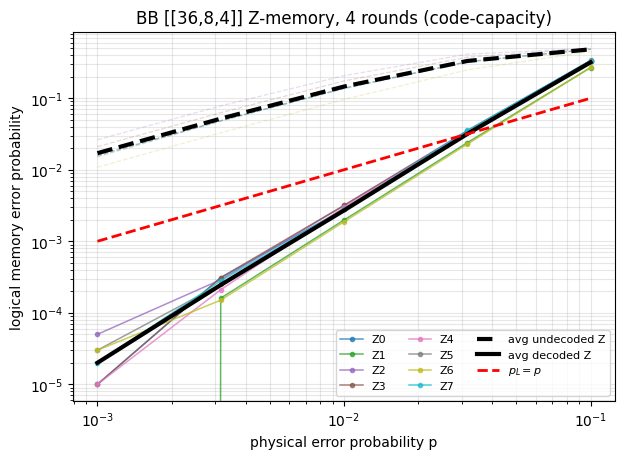

In [124]:
from bb_memory_sweeps import bb_run_memory_sweep

BB_code = BB36Code()
ps = np.logspace(-3, -1, 5)
shots = 100000
rounds=4
logical_indices = range(8)


def bb_plot_memory_sweep(result, ax=None):
    ps = result["ps"]
    raw = result["raw"]
    decoded = result["decoded"]
    basis = result["basis"]
    logical_indices = result["logical_indices"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.8))
    else:
        fig = ax.figure

    colors = [
        "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#4c78a8", "#54a24b", "#b279a2", "#72b7b2",
    ]
    for i, logical_i in enumerate(logical_indices):
        color = colors[i % len(colors)]
        ax.loglog(ps, raw[i], "--", color=color, alpha=0.22, linewidth=0.9)
        ax.loglog(ps, decoded[i], "o-", color=color, alpha=0.75, linewidth=1.1, markersize=3, label=f"{basis}{logical_i}")

    avg_decoded_memory = np.mean(decoded, axis=0)
    ax.loglog(ps, np.mean(raw, axis=0), "k--", linewidth=3.0, label=f"avg undecoded {basis}")
    ax.loglog(ps, avg_decoded_memory, "k-", linewidth=3.0, label=f"avg decoded {basis}")
    ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")
    ax.set_title(f"{result.get('code_label', 'BB code')} {basis}-memory, {result['rounds']} rounds (code-capacity)")
    ax.set_xlabel("physical error probability p")
    ax.set_ylabel("logical memory error probability")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()
    return fig, ax, avg_decoded_memory

bb_memory_results = {}
for bb_memory_basis in [Pauli.Z]:
    res = bb_run_memory_sweep(
        BB_code=BB_code,
        memory_basis=bb_memory_basis,
        ps=ps,
        rounds=rounds,
        shots=shots,
        noise_model="code-capacity",
        num_workers=128
    )
    bb_memory_results[res["basis"]] = res
    if bb_memory_basis == Pauli.Z:
        fig, ax, cc_avg_decoded_memory_z = bb_plot_memory_sweep(res)
    else:
        fig, ax, cc_avg_decoded_memory_x = bb_plot_memory_sweep(res)
    


logical 0: detectors=126, observables=1, L0 terms=1594
logical 1: detectors=126, observables=1, L0 terms=750
logical 2: detectors=126, observables=1, L0 terms=1820
logical 3: detectors=126, observables=1, L0 terms=1159
logical 4: detectors=126, observables=1, L0 terms=1282
logical 5: detectors=126, observables=1, L0 terms=825
logical 6: detectors=126, observables=1, L0 terms=577
logical 7: detectors=126, observables=1, L0 terms=1377
BB memory Z, p=1.00e-04, avg raw=0.008389, avg decoded=5.5e-06


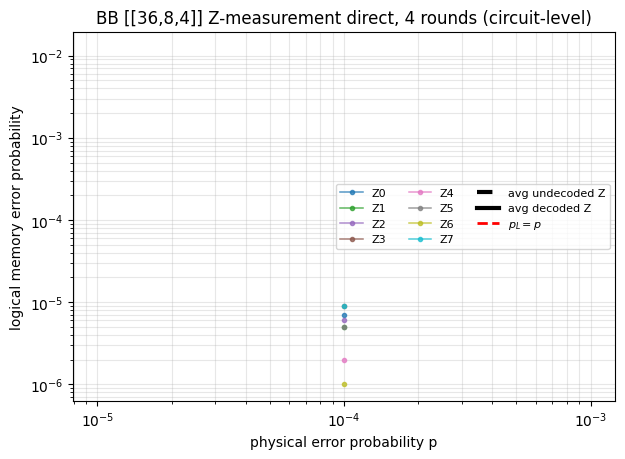

In [3]:
from bb_memory_sweeps import bb_run_memory_sweep

BB_code = BB36Code()
ps = np.logspace(-4, -4, 1)
shots = 1000000
rounds=4
logical_indices = range(8)

def bb_plot_memory_sweep(result, ax=None):
    ps = result["ps"]
    raw = result["raw"]
    decoded = result["decoded"]
    basis = result["basis"]
    logical_indices = result["logical_indices"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.8))
    else:
        fig = ax.figure

    colors = [
        "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#4c78a8", "#54a24b", "#b279a2", "#72b7b2",
    ]
    for i, logical_i in enumerate(logical_indices):
        color = colors[i % len(colors)]
        ax.loglog(ps, raw[i], "--", color=color, alpha=0.22, linewidth=0.9)
        ax.loglog(ps, decoded[i], "o-", color=color, alpha=0.75, linewidth=1.1, markersize=3, label=f"{basis}{logical_i}")

    avg_decoded_memory = np.mean(decoded, axis=0)
    ax.loglog(ps, np.mean(raw, axis=0), "k--", linewidth=3.0, label=f"avg undecoded {basis}")
    ax.loglog(ps, avg_decoded_memory, "k-", linewidth=3.0, label=f"avg decoded {basis}")
    ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")
    ax.set_title(f"{result.get('code_label', 'BB code')} {basis}-measurement direct, {result['rounds']} rounds (circuit-level)")
    ax.set_xlabel("physical error probability p")
    ax.set_ylabel("logical memory error probability")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()
    return fig, ax, avg_decoded_memory

bb_memory_results = {}
for bb_memory_basis in [Pauli.Z]:
    res = bb_run_memory_sweep(
        BB_code=BB_code,
        memory_basis=bb_memory_basis,
        ps=ps,
        rounds=rounds,
        shots=shots,
        noise_model="circuit-level",
        num_workers=128
    )
    bb_memory_results[res["basis"]] = res
    if bb_memory_basis == Pauli.Z:
        fig, ax, cl_avg_decoded_memory_z = bb_plot_memory_sweep(res)
    else:
        fig, ax, cl_avg_decoded_memory_x = bb_plot_memory_sweep(res)

## BB-36 logical measurement with gadget

Z00, p=1.00e-03, raw=0.03124, decoded=4e-05
Z00, p=3.16e-03, raw=0.09246, decoded=0.0003
Z00, p=1.00e-02, raw=0.2369, decoded=0.0038
Z00, p=3.16e-02, raw=0.4364, decoded=0.0436
Z00, p=1.00e-01, raw=0.5, decoded=0.384
Z01, p=1.00e-03, raw=0.03095, decoded=1e-05
Z01, p=3.16e-03, raw=0.09288, decoded=0.0002
Z01, p=1.00e-02, raw=0.2366, decoded=0.00228
Z01, p=3.16e-02, raw=0.4352, decoded=0.02971
Z01, p=1.00e-01, raw=0.4984, decoded=0.3226
Z02, p=1.00e-03, raw=0.05121, decoded=2e-05
Z02, p=3.16e-03, raw=0.1427, decoded=0.00041
Z02, p=1.00e-02, raw=0.3296, decoded=0.00358
Z02, p=3.16e-02, raw=0.4864, decoded=0.04313
Z02, p=1.00e-01, raw=0.501, decoded=0.3893
Z03, p=1.00e-03, raw=0.0418, decoded=1e-05
Z03, p=3.16e-03, raw=0.1205, decoded=0.00023
Z03, p=1.00e-02, raw=0.2882, decoded=0.0034
Z03, p=3.16e-02, raw=0.4678, decoded=0.04382
Z03, p=1.00e-01, raw=0.5005, decoded=0.384
Z04, p=1.00e-03, raw=0.03078, decoded=3e-05
Z04, p=3.16e-03, raw=0.09087, decoded=0.00026
Z04, p=1.00e-02, raw=0.2367,

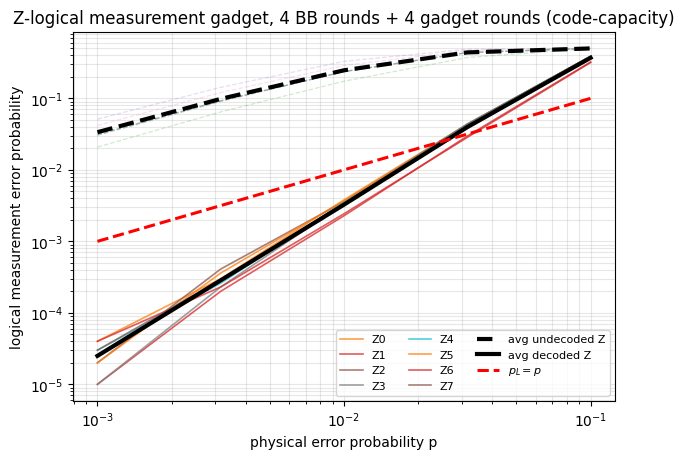

In [ ]:
# Code-capacity logical measurement gadget experiment
import bb_gadget_sweeps
from bb_gadget_sweeps import get_deformed_logical, estimate_logical_measurement_error_rate

BB_code = BB36Code()
ps = np.logspace(-3, -1, 5)
shots = 100000
bb_rounds=4
measurement_rounds=4
logical_indices = range(8)


logical_measurement_deformations = {}
logical_measurement_results = {}

for logical_basis, basis_name in [(Pauli.Z, 'Z')]:
    
    raw = np.zeros((len(logical_indices), len(ps)))
    decoded = np.zeros_like(raw)

    for i, logical_i in enumerate(logical_indices):
        def_res = get_deformed_logical(BB_code, logical_basis, logical_i)
        for j, p in enumerate(ps):
            raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
                BB_code=BB_code,
                def_res=def_res,
                logical_basis=logical_basis,
                logical_index=logical_i,
                p=float(p),
                measurement_rounds=measurement_rounds,
                bb_rounds=bb_rounds,
                shots=shots,
                noise_model = "code-capacity",
                noise_target="both",
                num_workers=128,
            )
            print(
                f'{basis_name}{logical_i:02d}, p={p:.2e}, '
                f'raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}'
            )

    logical_measurement_results[basis_name] = {
        'ps': ps.copy(),
        'raw': raw,
        'decoded': decoded,
    }

    fig, ax = plt.subplots(figsize=(7, 4.8))


    for i, logical_i in enumerate(logical_indices):
        ax.loglog(ps, raw[i], '--', alpha=0.22, linewidth=0.9)
        ax.loglog(
            ps,
            decoded[i],
            '-',
            alpha=0.75,
            linewidth=1.2,
            markersize=3,
            label=f'{basis_name}{logical_i}'
        )

    avg_raw = np.mean(raw, axis=0)
    if logical_basis == Pauli.Z:
        cc_avg_decoded_gadget_z = np.mean(decoded, axis=0)
    else:
        cc_avg_decoded_gadget_x = np.mean(decoded, axis=0)
    avg_decoded_gadget = np.mean(decoded, axis=0)
    ax.loglog(ps, avg_raw, 'k--', linewidth=3.0, label=f'avg undecoded {basis_name}')
    ax.loglog(ps, avg_decoded_gadget, 'k-', linewidth=3.0, label=f'avg decoded {basis_name}')

    # pseudo-threshold reference line: logical error = physical error
    ax.loglog(ps, ps, '--', color='red', linewidth=2.2, label=r'$p_L = p$')

    ax.set_title(f'{basis_name}-logical measurement gadget, {bb_rounds} BB rounds + {measurement_rounds} gadget rounds (code-capacity)')
    ax.set_xlabel('physical error probability p')
    ax.set_ylabel('logical measurement error probability')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()




In [ ]:

import importlib
import bb_gadget_sweeps
from bb_gadget_sweeps import get_deformed_logical, estimate_logical_measurement_error_rate

importlib.reload(bb_gadget_sweeps)

BB_code = BB36Code()
ps = np.logspace(-4, -4, 1)
shots = 1000000
bb_rounds=4
measurement_rounds=4
logical_indices = range(8)


logical_measurement_deformations = {}
logical_measurement_results = {}

for logical_basis, basis_name in [(Pauli.Z, 'Z')]:
    
    raw = np.zeros((len(logical_indices), len(ps)))
    decoded = np.zeros_like(raw)

    for i, logical_i in enumerate(logical_indices):
        def_res = get_deformed_logical(BB_code, logical_basis, logical_i)
        for j, p in enumerate(ps):
            raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
                BB_code=BB_code,
                def_res=def_res,
                logical_basis=logical_basis,
                logical_index=logical_i,
                p=float(p),
                measurement_rounds = measurement_rounds,
                bb_rounds = bb_rounds,
                shots=shots,
                noise_model = "circuit-level",
                noise_target="both",
                num_workers=128,
            )
            print(
                f'{basis_name}{logical_i:02d}, p={p:.2e}, '
                f'raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}'
            )

    logical_measurement_results[basis_name] = {
        'ps': ps.copy(),
        'raw': raw,
        'decoded': decoded,
    }

    fig, ax = plt.subplots(figsize=(7, 4.8))


    for i, logical_i in enumerate(logical_indices):
        ax.loglog(ps, raw[i], '--', alpha=0.22, linewidth=0.9)
        ax.loglog(
            ps,
            decoded[i],
            '-',
            alpha=0.75,
            linewidth=1.2,
            markersize=3,
            label=f'{basis_name}{logical_i}'
        )

    avg_raw = np.mean(raw, axis=0)
    if logical_basis == Pauli.Z:
        cl_avg_decoded_gadget_z = np.mean(decoded, axis=0)
    else:
        cl_avg_decoded_gadget_x = np.mean(decoded, axis=0)
    avg_decoded_gadget = np.mean(decoded, axis=0)
    ax.loglog(ps, avg_raw, 'k--', linewidth=3.0, label=f'avg undecoded {basis_name}')
    ax.loglog(ps, avg_decoded_gadget, 'k-', linewidth=3.0, label=f'avg decoded {basis_name}')

    # pseudo-threshold reference line: logical error = physical error
    ax.loglog(ps, ps, '--', color='red', linewidth=2.2, label=r'$p_L = p$')

    ax.set_title(f'{basis_name}-logical measurement gadget, {bb_rounds} BB rounds + {measurement_rounds} gadget rounds (circuit-level)')
    ax.set_xlabel('physical error probability p')
    ax.set_ylabel('logical measurement error probability')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()

Z00, p=1.00e-04, raw=0.01732, decoded=1e-05


# Direct measurement vs. graph measurment

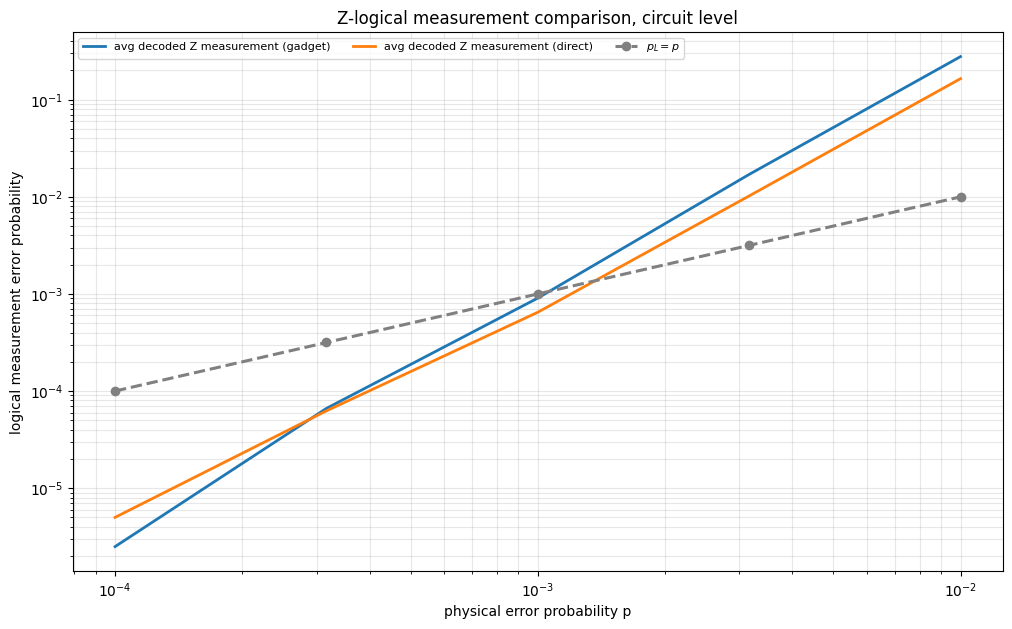

In [131]:
fig, ax = plt.subplots(figsize=(12, 7))
ps = np.logspace(-4, -2, 5)

ax.loglog(ps, cl_avg_decoded_gadget_z, '-', linewidth=2.0, label=f'avg decoded Z measurement (gadget)')
ax.loglog(ps, cl_avg_decoded_memory_z, "-", linewidth=2.0, label =f"avg decoded Z measurement (direct)")
#ax.loglog(ps, avg_decoded_gadget_x, '-', linewidth=2.0, label=f'avg decoded X measurement (gadget)')
#ax.loglog(ps, avg_decoded_memory_x, "-", linewidth=2.0, label =f"avg decoded X measurement (direct)")

# pseudo-threshold reference line: logical error = physical error
ax.loglog(ps, ps, 'o--', color='grey', linewidth=2.2, label=r'$p_L = p$')

ax.set_title(f'{basis_name}-logical measurement comparison, circuit level')
ax.set_xlabel('physical error probability p')
ax.set_ylabel('logical measurement error probability')
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.show()


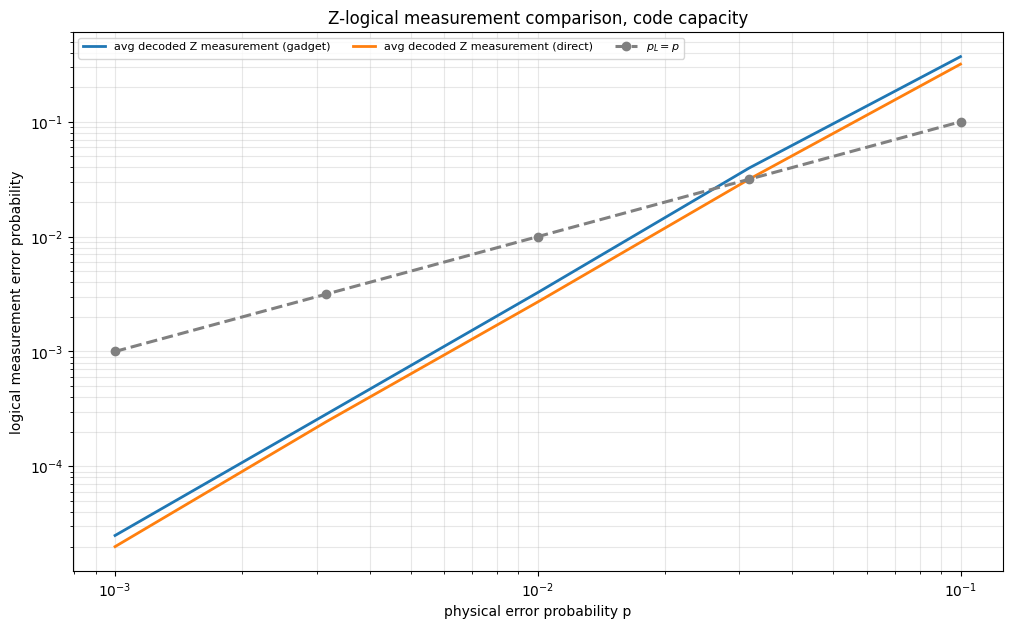

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
ps = np.logspace(-3, -1, 5)

ax.loglog(ps, cc_avg_decoded_gadget_z, '-', linewidth=2.0, label=f'avg decoded Z measurement (gadget)')
ax.loglog(ps, cc_avg_decoded_memory_z, "-", linewidth=2.0, label =f"avg decoded Z measurement (direct)")
#ax.loglog(ps, avg_decoded_gadget_x, '-', linewidth=2.0, label=f'avg decoded X measurement (gadget)')
#ax.loglog(ps, avg_decoded_memory_x, "-", linewidth=2.0, label =f"avg decoded X measurement (direct)")

# pseudo-threshold reference line: logical error = physical error
ax.loglog(ps, ps, 'o--', color='grey', linewidth=2.2, label=r'$p_L = p$')

ax.set_title(f'{basis_name}-logical measurement comparison, code capacity')
ax.set_xlabel('physical error probability p')
ax.set_ylabel('logical measurement error probability')
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.show()

## Shuttling vs. planarity (need larger code)

In [140]:
# shuttling_thresholds = [0,1,3]
# ps = np.logspace(-3.5, -2, 4)
# logical_basis = Pauli.Z
# basis_name = "Z"
# logical_i = 3
# shots = 100000
# rounds = 4
# raw = np.zeros((len(shuttling_thresholds), len(ps)))
# decoded = np.zeros_like(raw)
# n_shuttles = []

# for i, thresh in enumerate(shuttling_thresholds):
#     deformation = get_deformed_logical(
#         BB_code,
#         logical_basis=logical_basis,
#         logical_index=logical_i,
#         shuttling_threshold=thresh,
#     )
#     n_shuttles.append(deformation["n_shuttling_edges"])

#     for j, p in enumerate(ps):
#         raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
#             BB_code=BB_code,
#             def_res=deformation,
#             logical_basis=logical_basis,
#             logical_index=logical_i,
#             p=float(p),
#             rounds=rounds,
#             shots=shots,
#             noise_model="circuit-level",
#         )
#         print(
#             f"{basis_name}{logical_i:02d}, threshold={thresh}, "
#             f"shuttles={n_shuttles[-1]}, p={p:.2e}, "
#             f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
#         )

# shuttling_sweep_results = {
#     "ps": ps.copy(),
#     "thresholds": np.asarray(shuttling_thresholds),
#     "n_shuttles": np.asarray(n_shuttles),
#     "raw": raw,
#     "decoded": decoded,
# }



In [139]:
# fig, ax = plt.subplots(figsize=(7, 4.8))

# for i, thresh in enumerate(shuttling_thresholds):
#     label = f"threshold {thresh}, {n_shuttles[i]} shuttles"
#     ax.loglog(ps, raw[i], "--",  alpha=0.35, linewidth=1.0)
#     ax.loglog(ps, decoded[i], "o-", linewidth=1.4, markersize=3, label=label)

# ax.loglog(ps, ps, "--", color="grey", linewidth=2.0, label=r"$p_L=p$")

# ax.set_title(f"{basis_name}{logical_i} logical measurement vs shuttling threshold")
# ax.set_xlabel("physical error probability p")
# ax.set_ylabel("logical measurement error probability")
# ax.grid(True, which="both", alpha=0.3)
# ax.legend(fontsize=8)
# plt.show()

## Heterogenous noise

In [ ]:
import importlib
import bb_gadget_sweeps
importlib.reload(bb_gadget_sweeps)
from bb_gadget_sweeps import get_deformed_logical, estimate_logical_measurement_error_rate

ps = np.logspace(-4, -2, 3)
logical_basis = Pauli.Z
basis_name = "Z"
logical_i = 3
bb_rounds = 4
measurement_rounds = 4
raw = np.zeros((3, len(ps)))
decoded = np.zeros_like(raw)
noise_targets = ["gadget", "data", "both"]
BB_code = BB36Code()


deformation = get_deformed_logical(
        BB_code,
        logical_basis=logical_basis,
        logical_index=logical_i,
        shuttling_threshold=2,
    )

for i in range(3):
    for j, p in enumerate(ps):
        if p <= 1e-3:
            raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
                BB_code=BB_code,
                def_res=deformation,
                logical_basis=logical_basis,
                logical_index=logical_i,
                p=float(p),
                measurement_rounds=measurement_rounds,
                bb_rounds=bb_rounds,
                shots=10000000,
                noise_model = "circuit-level",
                noise_target = noise_targets[i],
                num_workers=128,

            )
            print(
                f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
                )
        
        else:
            raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
                BB_code=BB_code,
                def_res=deformation,
                logical_basis=logical_basis,
                logical_index=logical_i,
                p=float(p),
                measurement_rounds=measurement_rounds,
                bb_rounds=bb_rounds,
                shots=1000000,
                noise_model = "circuit-level",
                noise_target = noise_targets[i],
                num_workers=128

            )
            print(
                f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
            )

heterogenous_noise_results = {
    "ps": ps.copy(),
    "noise_targets":  noise_targets,
    "raw": raw,
    "decoded": decoded,
}

raw=0.005063, decoded=2.6e-06
raw=0.04854, decoded=0.0002775
raw=0.321, decoded=0.05011
raw=0.02417, decoded=5.6e-06


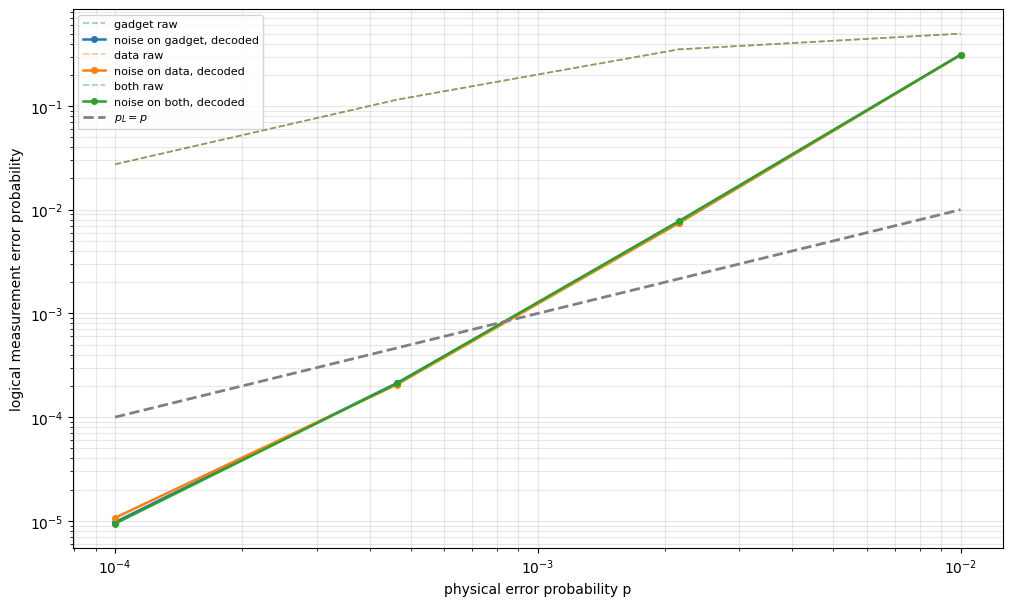

In [ ]:
res = heterogenous_noise_results
ps = res["ps"]
#rounds = 
noise_targets = res["noise_targets"]
raw = res["raw"]
decoded = res["decoded"]
colors =  ["C0", "C1", "C2"] 


fig, ax = plt.subplots(figsize=(12, 7))

for i, noise_target in enumerate(noise_targets):
    ax.loglog(
        ps,
        raw[i],
        "--",
        alpha=0.45,
        linewidth=1.2,
        label=f"{noise_target} raw",
    )
    ax.loglog(
        ps,
        decoded[i],
        "o-",
        linewidth=1.8,
        markersize=4,
        color = colors[i],
        label=f"noise on {noise_target}, decoded",
    )

ax.loglog(ps, ps, "--", color="grey", linewidth=2.0, label=r"$p_L=p$")

#ax.set_title(f"{basis_name}{logical_i} logical measurement, threshold=2, {rounds} rounds")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

In [13]:
print(decoded[0])

[9.70000e-06 2.12800e-04 7.44200e-03 3.11779e-01]


## Merge

In [ ]:
import importlib
import inter_code_merge_stim_sweep
from inter_code_merge_stim_sweep import estimate_merge_error_rate

importlib.reload(inter_code_merge_stim_sweep)

merge_ps = np.logspace(-4, -2, 5)

raw = []
decoded = []

logical1_index = 0
logical2_index = 0
rounds = 4
shots = 1000000

for p in merge_ps:
    r, d = estimate_merge_error_rate(
        BB_code,
        p=float(p),
        rounds=rounds,
        shots=shots,
        logical1_index=logical1_index,
        logical2_index=logical2_index,
        shuttling_threshold=10,
        noise_model="circuit-level",
        num_workers=128,
    )
    raw.append(r)
    decoded.append(d)
    print(f"Z{logical1_index}Z{logical2_index}, p={p:.2e}, raw={r:.4g}, decoded={d:.4g}")


Z0Z0, p=1.00e-03, raw=0.06039, decoded=5.9e-05
Z0Z0, p=3.16e-03, raw=0.1672, decoded=0.000715
Z0Z0, p=1.00e-02, raw=0.3629, decoded=0.007249
Z0Z0, p=3.16e-02, raw=0.492, decoded=0.08252
Z0Z0, p=1.00e-01, raw=0.5, decoded=0.4743


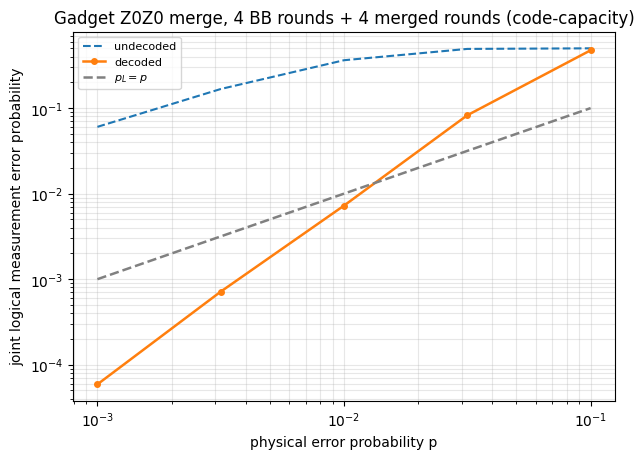

In [ ]:
label = "Z"
fig, ax = plt.subplots(figsize=(7, 4.8))

ax.loglog(merge_ps, raw, "--", label="undecoded")

ax.loglog(merge_ps, decoded, "o-", label="decoded", linewidth=1.8, markersize=4)
ax.loglog(merge_ps, merge_ps, "--", color="gray", linewidth=1.8, label=r"$p_L=p$")
ax.set_title(f"Gadget Z0Z0 merge, 4 BB rounds + 4 merged rounds (circuit-level)")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("joint logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()


In [4]:
import importlib
import inter_code_merge_stim_sweep
from inter_code_merge_stim_sweep import estimate_merge_error_rate

importlib.reload(inter_code_merge_stim_sweep)

merge_ps = np.logspace(-4, -2, 5)

cl_raw = []
cl_decoded = []

logical1_index = 0
logical2_index = 0
rounds = 4
shots = 1000000

for p in merge_ps:
    if p <= 1e-4:
        r, d = estimate_merge_error_rate(
            BB_code,
            p=float(p),
            rounds=rounds,
            shots=1000000,
            logical1_index=logical1_index,
            logical2_index=logical2_index,
            shuttling_threshold=0,
            noise_model="circuit-level",
            num_workers=128,
        )
    else: 
        r, d = estimate_merge_error_rate(
                    BB_code,
                    p=float(p),
                    rounds=rounds,
                    shots=100000,
                    logical1_index=logical1_index,
                    logical2_index=logical2_index,
                    shuttling_threshold=0,
                    noise_model="circuit-level",
                    num_workers=128,
                )
    cl_raw.append(r)
    cl_decoded.append(d)
    print(f"Z{logical1_index}Z{logical2_index}, p={p:.2e}, raw={r:.4g}, decoded={d:.4g}")

Z0Z0, p=1.00e-04, raw=0.03407, decoded=1.3e-05
Z0Z0, p=3.16e-04, raw=0.0985, decoded=0.00015
Z0Z0, p=1.00e-03, raw=0.2525, decoded=0.00214
Z0Z0, p=3.16e-03, raw=0.4462, decoded=0.03823
Z0Z0, p=1.00e-02, raw=0.4991, decoded=0.4209


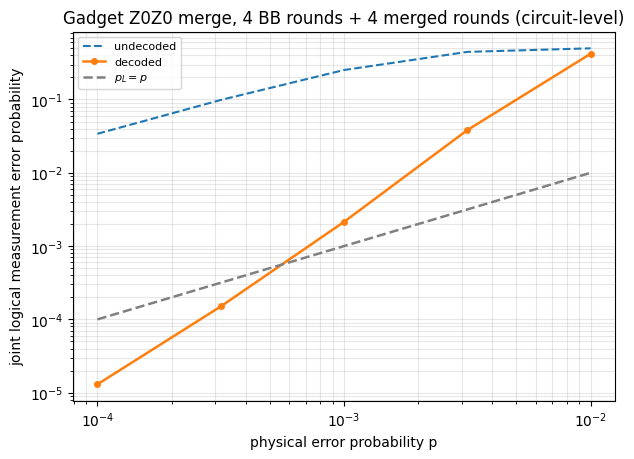

In [6]:
label = "Z"
fig, ax = plt.subplots(figsize=(7, 4.8))

ax.loglog(merge_ps, cl_raw, "--", label="undecoded")

ax.loglog(merge_ps, cl_decoded, "o-", label="decoded", linewidth=1.8, markersize=4)
ax.loglog(merge_ps, merge_ps, "--", color="gray", linewidth=1.8, label=r"$p_L=p$")
ax.set_title(f"Gadget Z0Z0 merge, 4 BB rounds + 4 merged rounds (circuit-level)")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("joint logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

Z0Z1, p=1.00e-03, raw=0.05041, decoded=3.4e-05
Z0Z1, p=3.16e-03, raw=0.1431, decoded=0.000388
Z0Z1, p=1.00e-02, raw=0.3282, decoded=0.004247
Z0Z1, p=3.16e-02, raw=0.4843, decoded=0.04921
Z0Z1, p=1.00e-01, raw=0.4996, decoded=0.4068


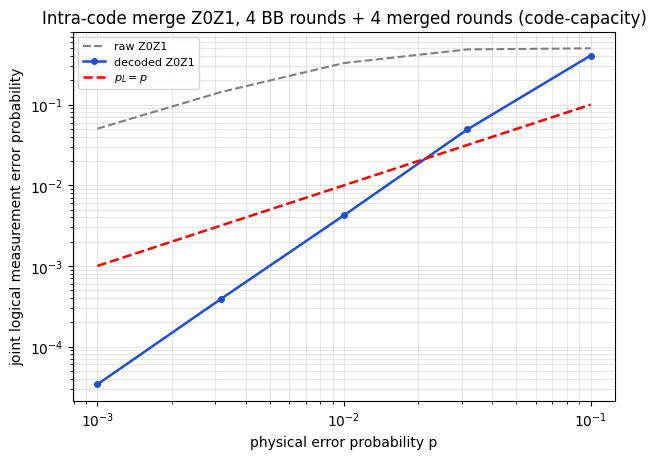

In [4]:
import numpy as np
from intra_code_merge_stim_sweep import estimate_intra_z_merge_error_rate

raw = []
decoded = []
last_circuit = None
last_merged = None
logical_indices=[0, 1]
ps = np.logspace(-3, -1, 5)
label = "".join(f"Z{int(i)}" for i in logical_indices)
for p in ps:
    r, d, last_circuit, last_merged = estimate_intra_z_merge_error_rate(
        BB_code,
        p=float(p),
        logical_indices=logical_indices,
        bb_rounds=4,
        measurement_rounds=4,
        shots=1000000,
        shuttling_threshold=2,
        noise_model="code-capacity",
        num_workers=128,
    )
    raw.append(r)
    decoded.append(d)
    print(f"{label}, p={p:.2e}, raw={r:.4g}, decoded={d:.4g}")


fig, ax = plt.subplots(figsize=(7, 4.8))
ax.loglog(ps, raw, "--", color="#7f7f7f", linewidth=1.5, label=f"raw {label}")
ax.loglog(ps, decoded, "o-", color="#1d4ed8", linewidth=1.8, markersize=4, label=f"decoded {label}")
ax.loglog(ps, ps, "--", color="red", linewidth=1.8, label=r"$p_L=p$")
ax.set_title( f"Intra-code merge {label}, 4 BB rounds + 4 merged rounds (code-capacity)")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("joint logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()


Z0Z1, p=1.00e-04, raw=0.03172, decoded=2.2e-05
Z0Z1, p=3.16e-04, raw=0.09351, decoded=0.0001
Z0Z1, p=1.00e-03, raw=0.2409, decoded=0.001298
Z0Z1, p=3.16e-03, raw=0.4373, decoded=0.02377
Z0Z1, p=1.00e-02, raw=0.4992, decoded=0.345


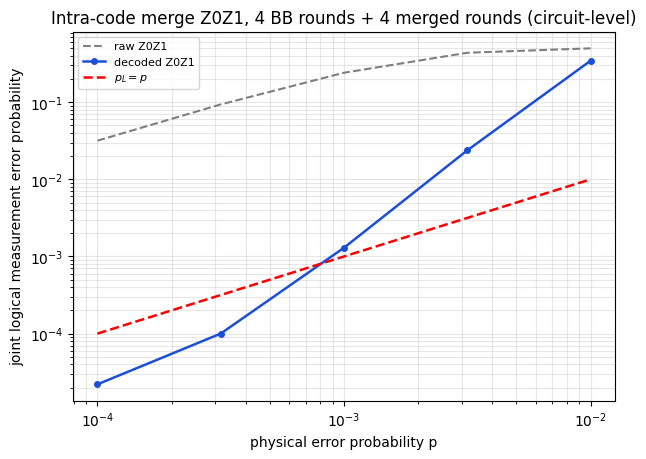

In [5]:
import numpy as np
from intra_code_merge_stim_sweep import estimate_intra_z_merge_error_rate

raw = []
decoded = []
last_circuit = None
last_merged = None
logical_indices=[0,1]
ps = np.logspace(-4, -2, 5)
label = "".join(f"Z{int(i)}" for i in logical_indices)
for p in ps:
    r, d, last_circuit, last_merged = estimate_intra_z_merge_error_rate(
        BB_code,
        p=float(p),
        logical_indices=logical_indices,
        bb_rounds=4,
        measurement_rounds=4,
        shots=1000000,
        shuttling_threshold=2,
        noise_model="circuit-level",
        num_workers=128,
    )
    raw.append(r)
    decoded.append(d)
    print(f"{label}, p={p:.2e}, raw={r:.4g}, decoded={d:.4g}")


fig, ax = plt.subplots(figsize=(7, 4.8))
ax.loglog(ps, raw, "--", color="#7f7f7f", linewidth=1.5, label=f"raw {label}")
ax.loglog(ps, decoded, "o-", color="#1d4ed8", linewidth=1.8, markersize=4, label=f"decoded {label}")
ax.loglog(ps, ps, "--", color="red", linewidth=1.8, label=r"$p_L=p$")
ax.set_title( f"Intra-code merge {label}, 4 BB rounds + 4 merged rounds (circuit-level)")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("joint logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()
